# 1.2 Training models with PyTorch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In Pytorch it is straight forward to make a training loop, for instance a small neural network to classify MNIST digits

## Load data`

In [2]:
mnist = pd.read_csv("local/data/mnist1.5k.csv.gz", compression="gzip", header=None).values
X=(mnist[:,1:785]/255.).astype(np.float32)
y=(mnist[:,0]).astype(int)
print("dimension de las imagenes y las clases", X.shape, y.shape)

dimension de las imagenes y las clases (1500, 784) (1500,)


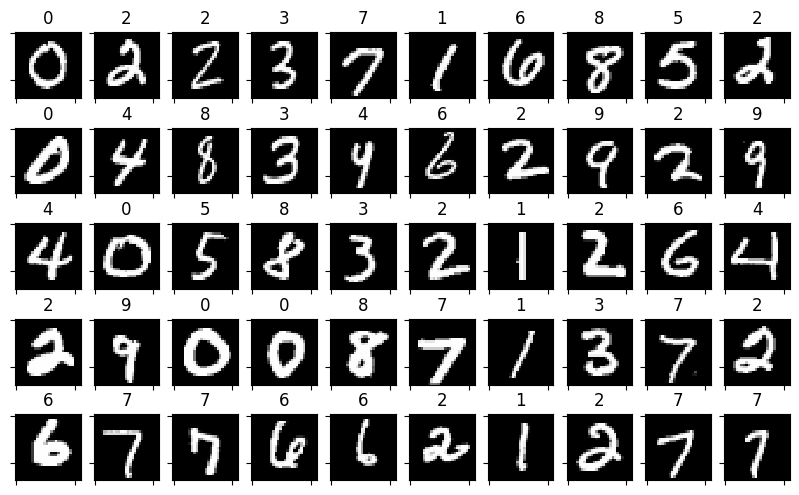

In [3]:
perm = np.random.permutation(list(range(X.shape[0])))[0:50]
random_imgs   = X[perm]
random_labels = y[perm]
fig = plt.figure(figsize=(10,6))
for i in range(random_imgs.shape[0]):
    ax=fig.add_subplot(5,10,i+1)
    plt.imshow(random_imgs[i].reshape(28,28), interpolation="nearest", cmap = plt.cm.Greys_r)
    ax.set_title(int(random_labels[i]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

## Split data and create data loaders

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1200, 784), (300, 784), (1200,), (300,))

In [5]:
tX_train = torch.from_numpy(X_train)
ty_train = torch.from_numpy(y_train)

tX_test = torch.from_numpy(X_test)
ty_test = torch.from_numpy(y_test)
tX_train, ty_train

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([0, 4, 4,  ..., 8, 5, 0]))

In [6]:
train_dataset = TensorDataset(tX_train, ty_train)
test_dataset = TensorDataset(tX_test, ty_test)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,      # Good practice for training
    num_workers=0      # Increase if on Linux/Mac for faster loading
)

## Create model

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.softmax(x, dim=1)
        return x

# Example instantiation
model = SimpleNN(input_size=X_train.shape[1], hidden_size=50, num_classes=10)
summary(model)

Layer (type:depth-idx)                   Param #
SimpleNN                                 --
├─Linear: 1-1                            39,250
├─Linear: 1-2                            510
Total params: 39,760
Trainable params: 39,760
Non-trainable params: 0

## Custom training loop

In [33]:
n_epochs = 20
model = SimpleNN(input_size=X_train.shape[1], hidden_size=50, num_classes=10)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

lossh = []
for epoch in range(n_epochs):
        model.train()  # IMPORTANT: Enables Dropout
        running_loss = 0.0

        # discard y
        for batch_idx, (x,y) in enumerate(train_loader):
            # Move data to GPU if available
            #data, target = data.to(device), target.to(device)
            
            # --- The Core Training Steps ---
            # 1. Clear gradients from the previous step
            optimizer.zero_grad()
            
            # 2. Forward pass: compute predicted outputs
            output = model(x)
            
            # 3. Calculate loss
            loss = loss_fn(output, y)
            
            # 4. Backward pass: compute gradient of the loss
            loss.backward()
            
            # 5. Optimization: update weights
            optimizer.step()
            
            running_loss += loss.item()

            lossh.append(loss.detach().numpy())
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")

Epoch 1/20 | Loss: 1.9546
Epoch 2/20 | Loss: 1.6776
Epoch 3/20 | Loss: 1.5939
Epoch 4/20 | Loss: 1.5685
Epoch 5/20 | Loss: 1.5453
Epoch 6/20 | Loss: 1.5237
Epoch 7/20 | Loss: 1.5175
Epoch 8/20 | Loss: 1.5064
Epoch 9/20 | Loss: 1.4975
Epoch 10/20 | Loss: 1.4955
Epoch 11/20 | Loss: 1.4976
Epoch 12/20 | Loss: 1.4929
Epoch 13/20 | Loss: 1.4939
Epoch 14/20 | Loss: 1.4911
Epoch 15/20 | Loss: 1.4926
Epoch 16/20 | Loss: 1.4938
Epoch 17/20 | Loss: 1.4950
Epoch 18/20 | Loss: 1.4928
Epoch 19/20 | Loss: 1.4938
Epoch 20/20 | Loss: 1.4828
Training Complete!


In [45]:
test_preds = model(tX_test).argmax(axis=-1)
test_acc = torch.mean((test_preds == ty_test)*1.)
print (f'accuracy in test {test_acc:.3f}')



accuracy in test 0.923


## Training with pytorch lightning

we include the training step and other stuff in our model class which must be derived from `LightningModule`

In [51]:
import lightning as L


In [73]:
class SimpleNN(L.LightningModule):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, num_classes)

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.softmax(x, dim=1)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        o = self.forward(x)
        loss = self.loss_fn(o, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01)
        return optimizer


we use a custom callback to record the loss history. There are many callbacks to report history to cloud services, to log files, etc.

In [74]:
from lightning.pytorch.callbacks import Callback

class LossHistory(Callback):
    def __init__(self):
        self.history = []

    def on_train_epoch_end(self, trainer, pl_module):
        # trainer.logged_metrics contains values logged via self.log()
        loss = trainer.logged_metrics.get("train_loss")
        if loss is not None:
            self.history.append(loss.item())

In [75]:

model = SimpleNN(input_size=X_train.shape[1], hidden_size=50, num_classes=10)

history_cb = LossHistory()

trainer = L.Trainer(max_epochs=20, callbacks=[history_cb]) # Configure the trainer
trainer.fit(model=model, train_dataloaders=train_loader) 


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer1  │ Linear           │ 39.2 K │ train │     0 │
│ 1 │ layer2  │ Linear           │    510 │ train │     0 │
│ 2 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 39.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 39.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


Text(0, 0.5, 'loss')

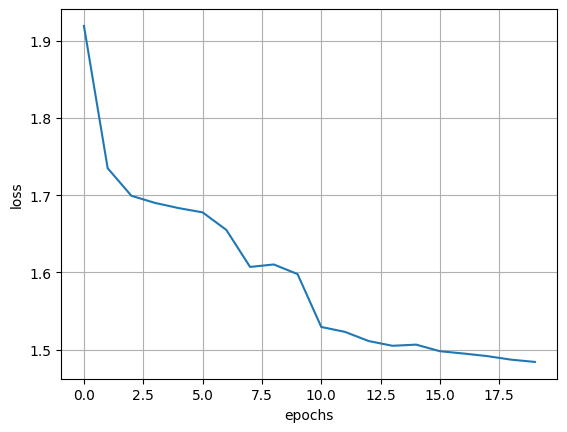

In [78]:
plt.plot(history_cb.history)
plt.grid()
plt.xlabel('epochs')
plt.ylabel('loss')

In [79]:
test_preds = model(tX_test).argmax(axis=-1)
test_acc = torch.mean((test_preds == ty_test)*1.)
print (f'accuracy in test {test_acc:.3f}')


accuracy in test 0.940
